**DATA LOADING AND CLEANING**

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


**LOADING BOTH THE DATA SETS**

In [15]:
fear_greed_df = pd.read_csv("fear_greed_index.csv")
trades_df = pd.read_csv("historical_data.csv")


In [16]:
fear_greed_df.head()


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [17]:
trades_df.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [18]:
fear_greed_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [20]:
fear_greed_df.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [21]:
fear_greed_df["classification"].value_counts()

classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64

In [22]:
trades_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

**CLEANING COLUMN NAMES**

In [23]:
trades_df.columns = trades_df.columns.str.strip().str.lower().str.replace(" ", "_")

In [24]:
trades_df.columns


Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')

In [25]:
trades_df[[
    "account",
    "coin",
    "execution_price",
    "size_usd",
    "side",
    "timestamp_ist",
    "closed_pnl"
]].head()


,account,coin,execution_price,size_usd,side,timestamp_ist,closed_pnl
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,7872.16,BUY,02-12-2024 22:50,0.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,127.68,BUY,02-12-2024 22:50,0.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,1150.63,BUY,02-12-2024 22:50,0.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,1142.04,BUY,02-12-2024 22:50,0.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,69.75,BUY,02-12-2024 22:50,0.0


CONVERTING TRADE TIMESTAMP (IST)

In [27]:
trades_df["timestamp_ist"] = pd.to_datetime(
    trades_df["timestamp_ist"],
    dayfirst=True
)

In [28]:
trades_df["timestamp_ist"].head(10)

0   2024-12-02 22:50:00
1   2024-12-02 22:50:00
2   2024-12-02 22:50:00
3   2024-12-02 22:50:00
4   2024-12-02 22:50:00
5   2024-12-02 22:50:00
6   2024-12-02 22:50:00
7   2024-12-02 22:50:00
8   2024-12-02 22:50:00
9   2024-12-02 22:50:00
Name: timestamp_ist, dtype: datetime64[ns]

In [29]:
trades_df["timestamp_ist"].isna().sum()

np.int64(0)

**CREATING A DAILY TRADE DATE COLUMN**

In [30]:
trades_df["trade_date"] = trades_df["timestamp_ist"].dt.date
trades_df["trade_date"] = pd.to_datetime(trades_df["trade_date"])

In [31]:
trades_df[["timestamp_ist", "trade_date"]].head()


,timestamp_ist,trade_date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [33]:
print(fear_greed_df)

       timestamp  value classification        date
0     1517463000     30           Fear  2018-02-01
1     1517549400     15   Extreme Fear  2018-02-02
2     1517635800     40           Fear  2018-02-03
3     1517722200     24   Extreme Fear  2018-02-04
4     1517808600     11   Extreme Fear  2018-02-05
...          ...    ...            ...         ...
2639  1745818200     54        Neutral  2025-04-28
2640  1745904600     60          Greed  2025-04-29
2641  1745991000     56          Greed  2025-04-30
2642  1746077400     53        Neutral  2025-05-01
2643  1746163800     67          Greed  2025-05-02

[2644 rows x 4 columns]


In [34]:
fear_greed_df.columns = (
    fear_greed_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [35]:
fear_greed_df.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [37]:
fear_greed_df["date"] = pd.to_datetime(fear_greed_df["date"])

**HANDLING MISSING VALUES**

In [38]:
trades_df = trades_df.dropna(subset=["closed_pnl"])

Analysis on Bitcoin trades. Checking available coins:

In [39]:
trades_df["coin"].value_counts().head()

coin
HYPE    68005
@107    29992
BTC     26064
ETH     11158
SOL     10691
Name: count, dtype: int64

**FILTERING BITCOINS**

In [40]:
btc_trades_df = trades_df[
    trades_df["coin"].str.contains("BTC", na=False)
]


**SELECTING FINAL WORKING COLUMNS**

In [42]:
btc_trades_df = btc_trades_df[
    [
        "account",
        "coin",
        "execution_price",
        "size_usd",
        "side",
        "timestamp_ist",
        "trade_date",
        "closed_pnl"
    ]
]


**TOP 5 BITCOINS PREVIEW**

In [43]:
btc_trades_df.head()


,account,coin,execution_price,size_usd,side,timestamp_ist,trade_date,closed_pnl
3001,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,7061.59,BUY,2025-03-17 04:48:00,2025-03-17,0.0
3002,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,9999.74,BUY,2025-03-17 04:48:00,2025-03-17,0.0
3003,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,770.73,BUY,2025-03-17 04:48:00,2025-03-17,0.0
3004,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,10176.59,BUY,2025-03-17 04:48:00,2025-03-17,0.0
3005,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,217804.66,BUY,2025-03-17 04:48:00,2025-03-17,0.0


**SAVING CLEANED FILES**

In [45]:
btc_trades_df.to_csv("btc_trades_cleaned.csv", index=False)
fear_greed_df.to_csv("fear_greed_cleaned.csv", index=False)

**MERGING TRADER DATA WITH SENTIMENT DATA**

In [46]:
merged_df = pd.merge(
    btc_trades_df,
    fear_greed_df,
    left_on="trade_date",
    right_on="date",
    how="inner"
)

In [47]:
merged_df.head()


,account,coin,execution_price,size_usd,side,timestamp_ist,trade_date,closed_pnl,timestamp,value,classification,date
0,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,7061.59,BUY,2025-03-17 04:48:00,2025-03-17,0.0,1742189400,32,Fear,2025-03-17
1,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,9999.74,BUY,2025-03-17 04:48:00,2025-03-17,0.0,1742189400,32,Fear,2025-03-17
2,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,770.73,BUY,2025-03-17 04:48:00,2025-03-17,0.0,1742189400,32,Fear,2025-03-17
3,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,10176.59,BUY,2025-03-17 04:48:00,2025-03-17,0.0,1742189400,32,Fear,2025-03-17
4,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,217804.66,BUY,2025-03-17 04:48:00,2025-03-17,0.0,1742189400,32,Fear,2025-03-17


In [50]:
merged_df.head()


,account,coin,execution_price,size_usd,side,timestamp_ist,trade_date,closed_pnl,timestamp,value,classification,date
0,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,7061.59,BUY,2025-03-17 04:48:00,2025-03-17,0.0,1742189400,32,Fear,2025-03-17
1,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,9999.74,BUY,2025-03-17 04:48:00,2025-03-17,0.0,1742189400,32,Fear,2025-03-17
2,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,770.73,BUY,2025-03-17 04:48:00,2025-03-17,0.0,1742189400,32,Fear,2025-03-17
3,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,10176.59,BUY,2025-03-17 04:48:00,2025-03-17,0.0,1742189400,32,Fear,2025-03-17
4,0x513b8629fe877bb581bf244e326a047b249c4ff1,BTC,82255.0,217804.66,BUY,2025-03-17 04:48:00,2025-03-17,0.0,1742189400,32,Fear,2025-03-17


In [52]:
merged_df.shape


(26064, 12)

**CORE ANALYSIS**

*Average PnL: Fear vs Greed*

In [53]:
avg_pnl = merged_df.groupby("classification")["closed_pnl"].mean()
avg_pnl

classification
Extreme Fear      1.731921
Extreme Greed    41.413264
Fear             48.900673
Greed            15.949612
Neutral          34.921175
Name: closed_pnl, dtype: float64

**Insight: Traders on an average makes most money in 'Fear'. While the difference between "Extreme Greed" and 'Fear' isn't that high.
Even Neutral Traders are making a fair sum of money as well.**

*Median PnL*

In [55]:
median_pnl = merged_df.groupby("classification")["closed_pnl"].median()
median_pnl

classification
Extreme Fear     0.0
Extreme Greed    0.0
Fear             0.0
Greed            0.0
Neutral          0.0
Name: closed_pnl, dtype: float64

**Total PnL by sentiment**

In [56]:
total_pnl = merged_df.groupby("classification")["closed_pnl"].sum()
total_pnl

classification
Extreme Fear       3056.840313
Extreme Greed    100882.711093
Fear             482649.644056
Greed            115475.191549
Neutral          165980.345627
Name: closed_pnl, dtype: float64

*Most profit making trades was done when traders were in a fear state.*

**Number of Trades during Fear vs Greed**

In [57]:
trade_count = merged_df.groupby("classification")["closed_pnl"].count()
trade_count


classification
Extreme Fear     1765
Extreme Greed    2436
Fear             9870
Greed            7240
Neutral          4753
Name: closed_pnl, dtype: int64

*Most trades were made in the state of either fear or Greed.*

**Visualizations**

*Average PnL*

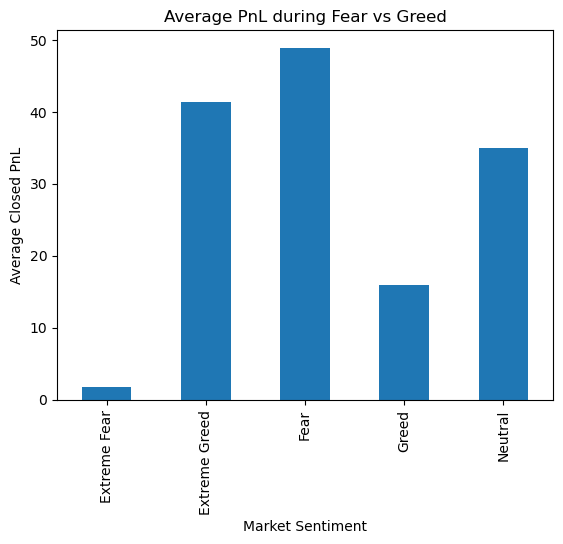

In [58]:
avg_pnl.plot(kind="bar")
plt.title("Average PnL during Fear vs Greed")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.show()


**Trade Count**

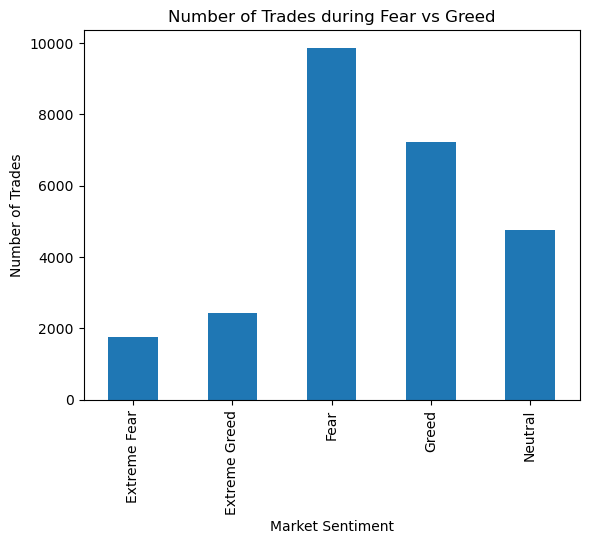

In [59]:
trade_count.plot(kind="bar")
plt.title("Number of Trades during Fear vs Greed")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.show()

**PnL distribution**

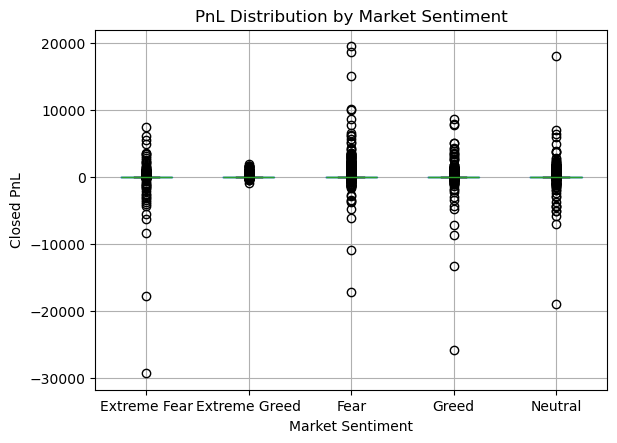

In [60]:
merged_df.boxplot(
    column="closed_pnl",
    by="classification"
)

plt.title("PnL Distribution by Market Sentiment")
plt.suptitle("")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")
plt.show()
